# Test of Gaussian Process Inverse Methods
Newton Schulz inverse vs. Numpy Inverse vs. Cholseky

In [1]:
import numpy as np
import os 
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import GP
import inverses
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from functions import Newton_Shulz
from functions import RandomlyPivotedCholesky, forward_substitution_matrix, back_substitution_matrix

(30,)
(30,)
Computing inverse via Newton-Schulz method
No previous inverse stored
Using numpy for first inverse
[ 2.77283414e-10+1.23864741e-09j  2.77283414e-10-1.23864741e-09j
  1.07154098e-09+0.00000000e+00j -6.82326190e-10+1.17775477e-10j
 -6.82326190e-10-1.17775477e-10j  6.78116297e-10+0.00000000e+00j
  4.45397643e-10+3.61618694e-10j  4.45397643e-10-3.61618694e-10j
  2.51567545e-10+5.06203168e-10j  2.51567545e-10-5.06203168e-10j
  5.02869174e-10+0.00000000e+00j  2.66740653e-10+4.48196222e-10j
  2.66740653e-10-4.48196222e-10j -1.18140646e-10+4.98105679e-10j
 -1.18140646e-10-4.98105679e-10j -4.91635240e-10+0.00000000e+00j
 -1.06673262e-10+3.48346308e-10j -1.06673262e-10-3.48346308e-10j
  5.01192781e-12+3.46671294e-10j  5.01192781e-12-3.46671294e-10j
  2.59504370e-10+7.55406139e-11j  2.59504370e-10-7.55406139e-11j
 -3.40636937e-10+6.62670457e-11j -3.40636937e-10-6.62670457e-11j
 -2.22615197e-10+1.09271331e-10j -2.22615197e-10-1.09271331e-10j
  6.67536514e-11+1.44579863e-10j  6.6753651

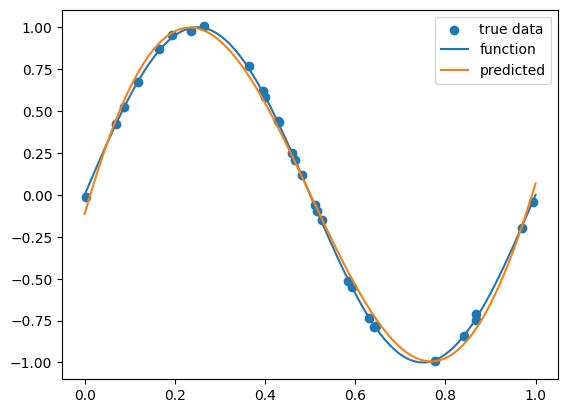

In [2]:
# make somme data
n = 30
sig = 0.01
x = np.random.rand(n)
# print(x)
y = np.sin(x* 2*np.pi) + sig*np.random.randn(n)

print(x.shape)
print(y.shape)

xth = np.linspace(0,1, 100)
yth = np.sin(xth * 2*np.pi)

# create a gaussian process object
gauss = GP.GPR(n, 1, "RBF", sig, inv_method = inverses.NewtonSchulzInv(True, True, precond="None"), verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss.fit(np.array([x]), y, theta=np.array([10, 1e-0])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

In [3]:
ni = inverses.NumpyInverse(True, True)
print(gauss.ker.mat.shape)
x = ni.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0])) @ x)
x2 = ni.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
ni.invalidateInverse()
x3 = ni.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))

(30, 30)
Computing inverse via numpy


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 20 is different from 30)

In [4]:
chol = inverses.Cholesky(True, True)
x = chol.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0])) @ x)

Computing cholesky factorization
forward sub has error 5.874748045952207e-16
back sub has error 2.085610285217977e-15
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [5]:
ns = inverses.NewtonSchulzInv(True, True, precond="None")
x = ns.vecSolve(gauss.ker.mat, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0])) @ x)

No previous inverse stored
Using numpy for first inverse
(5.332039510464666e-09+0j)
Using provided initial guess for Newton-Schulz
Current error = 0.004081325334756959
Current error = 0.006078653129095544
Current error = 0.004509065328115812
Current error = 0.005162283065261244
Current error = 0.0053868105544910595
Current error = 0.0048523267823713575
Current error = 0.004106960371198996
Current error = 0.005087465762862477
Current error = 0.00490257945784743
Current error = 0.005491245077929131
Current error = 0.004439952323661738
Current error = 0.0052822808596629306
Current error = 0.00459381979924691
Current error = 0.00554785164091099
Current error = 0.0039583758758059895
Current error = 0.0049468620087561544
Current error = 0.0044161319579779585
Current error = 0.0037828457197175203
Current error = 0.004504877233312485
Current error = 0.0032586189568652043
Current error = 0.00509339833554875
Current error = 0.006170626013237094
Current error = 0.004432511980013422
Current error 

In [6]:
B = np.random.randn(20,20)
pert = (1e-3)*B.T@B
x = ns.vecSolve(gauss.ker.mat + pert, gauss.sig, np.ones(20))
print((gauss.ker.mat+(gauss.sig**2)*np.eye(gauss.ker.mat.shape[0]) + pert) @ x)

[0.97553061 1.00240557 1.01536873 1.01494728 0.99342532 1.01797851
 0.98812059 1.02400446 1.00768587 0.99481122 1.00661867 0.98425998
 0.99671792 1.01323696 1.01148894 0.99929999 0.98069106 0.99444083
 1.002164   1.01571944]


## Note on Newton-Schulz
Newton Schulz preconditioning does not seem to help much for the simple examples I was doing. It is still in the code to play with but it currently doesn't seem to help all that much. 

In [7]:
B = np.random.randn(20,20)
print(ni.trInvMult(gauss.ker.mat, gauss.sig, B))
print(chol.trInvMult(gauss.ker.mat, gauss.sig, B))
print(ns.trInvMult(gauss.ker.mat, gauss.sig, B))

102955.99532874473
forward sub has error 2.138389964692763e-14
back sub has error 2.2960065052034767e-10
102955.9953073451
102955.99531926797


In [8]:
Khati = np.linalg.inv((gauss.sig**2)*np.eye(20) + gauss.ker.mat)
print(Khati @ B)
print(np.trace(Khati @ B))

[[ 8.76814174e+03 -5.73253841e+03 -5.20661154e+03 -6.90293813e+03
  -7.87405108e+03  5.00792378e+03  5.12762794e+03  5.67562238e+03
   9.00690741e+03 -7.98271733e+02 -3.16171429e+03 -1.54295397e+04
   3.17696188e+03  1.83256248e+03  8.64281664e+03  5.12195362e+03
   4.94588473e+03  9.69393903e+03  8.09579576e+03 -1.00220539e+03]
 [-1.93034926e+04  7.37685993e+03 -9.91954507e+03  1.19690361e+04
  -5.48283201e+03 -8.67261140e+03 -1.37212325e+04 -2.77220674e+03
   9.81472496e+03  2.97797564e+03 -2.24014401e+04  1.85591500e+03
  -3.19805252e+03  1.27792406e+04  6.14945515e+03  4.36551254e+03
   3.55956824e+03  4.21794764e+03 -1.39647369e+02 -5.07215737e+03]
 [-1.77587393e+03  1.66367175e+03  1.57074310e+02  2.01699861e+03
   3.40570268e+03  8.83046331e+02 -3.86706701e+03 -1.94065439e+03
  -1.73658165e+03  1.51354732e+03  1.49274860e+03  6.21406309e+03
   4.60768755e+02 -2.83282368e+03 -3.49306427e+03 -3.69604943e+03
  -8.03556885e+02 -6.27941933e+03 -3.09401717e+03  6.90706346e+02]
 [ 1.61

In [3]:
# try optimizing
gauss.grad_dec_theta(np.array([0.1, 0.1]), alpha=1e-5)
new_y = gauss.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 = [0.1 0.1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Iteration 0
theta =  [0.1 0.1]
[1.98640369e-01+0.00000000e+00j 6.87743819e-02+0.00000000e+00j
 2.71473497e-02+0.00000000e+00j 4.83790226e-03+0.00000000e+00j
 9.55217254e-04+0.00000000e+00j 2.33011704e-04+0.00000000e+00j
 1.10859162e-04+0.00000000e+00j 1.00841617e-04+0.00000000e+00j
 1.00062957e-04+0.00000000e+00j 1.00003800e-04+0.00000000e+00j
 1.00000291e-04+0.00000000e+00j 1.00000009e-04+0.00000000e+00j
 1.00000000e-04+0.00000000e+00j 1.00000000e-04+0.00000000e+00j
 1.00000000e-04+0.00000000e+00j 1.00000000e-04+0.00000000e+00j
 1.00000000e-04+0.00000000e+00j 1.00000000e-04+0.00000000e+00j
 1.00000000e-04+2.11636500e-18j 1.00000000e-04-2.11636500e-18j
 1.00000000e-04+0.00000000e+00j 1.00000000e-04+0.00000000e+00j
 1.00000000e-04+0.00000000e+00j 1.00000000e-04+3.41378448e-19j
 1.00000000e-04-3.41378448e-19j 1.00000000e-04+0.00000000e+00j
 1.00000000e-04+1.4969

/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/.env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:202: LogmNearlySingularWarning: The logm input matrix may be nearly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/.env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:202: LogmExactlySingularWarning: The logm input matrix is exactly singular.
  F = scipy.linalg._matfuncs_inv_ssq._logm(A)
/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/.env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:373: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw


ValueError: array must not contain infs or NaNs

In [ ]:
# create a gaussian process object
gauss_no_ns = GP.GPR(n, 1, "RBF", sig, use_ns=False, verbose=True)
# fit the gaussian process to the given data, for some sigma_f and l
gauss_no_ns.fit(np.array([x]), y, theta=np.array([10, 1e-3])) # changing the hyperparameters gives you different fits
# new_x = np.random.rand(5)
new_y = gauss_no_ns.predict_aft_K(xth)

In [ ]:
# try optimizing
gauss_no_ns.grad_dec_theta(np.array([1, 1]), alpha=1e-5)
new_y = gauss_no_ns.predict_aft_K(xth)

fig = plt.figure()
plt.scatter(x, y, label="true data")
plt.plot(xth, yth, label="function")
plt.plot(xth, new_y, label="predicted")

plt.legend()

Running gradient descent with theta0 = [1 1]
Using a stopping condition of ||nabla f||^2 < 1e-05
Using a step size of 1e-05
Iteration 0
theta =  [1 1]
log liklihood = -1736.2853938448663
Iteration 1
theta =  [42.82477856  0.97921211]
log liklihood = 0.4240177403501022
Iteration 2
theta =  [123.50382021   0.97881149]
log liklihood = 18.296195269316613
Iteration 3
theta =  [168.35044208   0.97867907]
log liklihood = 19.527268788694812
Iteration 4
theta =  [218.9465155    0.97862032]
log liklihood = 19.566414721606428
Iteration 5
theta =  [279.96144291   0.97858443]
log liklihood = 19.045423263239513
Iteration 6
theta =  [354.9035947    0.97858527]
log liklihood = 18.202389019587905
Iteration 7
theta =  [447.40805141   0.97849569]
log liklihood = 17.15954932188994
Iteration 8
theta =  [561.92799361   0.97830905]
log liklihood = 15.982132286046983
Iteration 9
theta =  [704.36857398   0.97859515]
log liklihood = 14.707213550806635
Iteration 10
theta =  [882.59992579   0.97935602]
log liklih

/home/trevor/Documents/School/Grad_school/research/Newton_shulz/Newton_Shulz/gauss_proc/GP.py:209: RuntimeWarning: logm result may be inaccurate, approximate err = 6.631520139596099e-13
  logKhat = scil.logm(Khat)


LinAlgError: Singular matrix